# 🟡 K-Nearest Neighbors (KNN)
---

## 📑 Table of Contents
1. [Introduction & Definition](#1.-Introduction-&-Definition)
2. [How It Works — Math & Intuition](#2.-How-It-Works-—-Math-&-Intuition)
3. [When To Use](#3.-When-To-Use)
4. [Pros & Cons](#4.-Pros-&-Cons)
5. [Dataset Upload & Exploration](#5.-Dataset-Upload-&-Exploration)
   - 5.1 Import Libraries
   - 5.2 Load Dataset
   - 5.3 Exploratory Data Analysis (EDA)
   - 5.4 Preprocessing & Feature Engineering
6. [Training the Model](#6.-Training-the-Model)
   - 6.1 Train/Validation/Test Split
   - 6.2 Fit the Model
7. [Validation](#7.-Validation)
   - 7.1 Cross-Validation
   - 7.2 Finding Optimal K
8. [Testing](#8.-Testing)
   - 8.1 Final Test Set Evaluation
   - 8.2 Confusion Matrix & Classification Report
9. [Optimization / Hyperparameter Tuning](#9.-Optimization-/-Hyperparameter-Tuning)
   - 9.1 GridSearchCV
   - 9.2 Best Parameters & Retrain
10. [Decision Boundary Visualization](#10.-Decision-Boundary-Visualization)
11. [Tips & Tricks Summary](#11.-Tips-&-Tricks-Summary)
12. [Conclusion](#12.-Conclusion)

## 1. Introduction & Definition
**K-Nearest Neighbors (KNN)** is one of the simplest, most intuitive, and yet surprisingly effective classification algorithms in machine learning. Unlike parametric models such as Logistic Regression or SVM, which learn a fixed set of parameters during training, KNN is a **non-parametric, instance-based, lazy learning** algorithm — it makes no assumptions about the underlying data distribution and defers all computation to prediction time.

### Lazy Learning
In traditional parametric machine learning algorithms, there is an explicit training phase where the model learns coefficients or weights to minimize an objective function. Once training is complete, the training data can be discarded, and the compact mathematical representation is used for inference. KNN takes the opposite approach. It is known as a **lazy learner** because it does absolutely no work during the training phase. The "training" step simply consists of storing the entire training dataset in memory. All of the heavy computational lifting is postponed until a prediction is required.

### Instance-Based Learning
KNN is an **instance-based** algorithm, meaning it makes predictions for new data points by comparing them to similar instances in the training set. The core philosophy is that similar data points exist in close proximity to one another. When asked to classify a new observation, KNN searches the stored dataset for the most similar instances (the "neighbors") and aggregates their labels to form a prediction.

### Distance Metrics
To determine which data points are the most "similar" or "nearest", KNN relies on a distance metric. The choice of distance metric fundamentally changes how the algorithm perceives the input space.
- **Euclidean Distance (L2 Norm)**: The most common choice for continuous data. It represents the straight-line distance between two points. $d(x,y) = \sqrt{\sum_{i=1}^{p} (x_i - y_i)^2}$
- **Manhattan Distance (L1 Norm)**: Also known as city-block distance, it calculates the absolute differences across dimensions. It is often preferred for high-dimensional or sparse data. $d(x,y) = \sum_{i=1}^{p} |x_i - y_i|$
- **Minkowski Distance**: A generalized metric that encompasses both Euclidean and Manhattan distances, controlled by a parameter $p$. $d(x,y) = (\sum_{i=1}^{p} |x_i - y_i|^p)^{1/p}$. When $p=1$, it is Manhattan; when $p=2$, it is Euclidean.
- **Cosine Similarity**: Measures the angle between two vectors rather than the magnitude. It is extensively used in text classification and natural language processing.

### The Role of K
The hyperparameter $K$ represents the number of nearest neighbors to consider. 
- If **$K=1$**, the model simply predicts the label of the single closest point. This leads to a highly complex, jagged decision boundary that perfectly memorizes the training data (low bias), but is extremely sensitive to noise (high variance).
- If **$K=N$** (where N is the total number of training samples), the algorithm simply predicts the majority class of the entire dataset for every query. This results in a completely rigid model that ignores local variations (high bias, low variance).

### Voting Schemes
When deciding on the final label among the $K$ neighbors, two primary voting schemes are used:
- **Uniform Voting**: Every neighbor gets an equal vote (weight = 1). The most frequent class wins.
- **Distance-Weighted Voting**: Neighbors that are closer to the query point are given higher influence. The vote is weighted by the inverse of the distance ($w = 1/d$). This helps mitigate the effect of choosing a $K$ value that might include somewhat distant neighbors.

### The Curse of Dimensionality
KNN suffers dramatically from the **Curse of Dimensionality**. As the number of features (dimensions) $p \rightarrow \infty$, the volume of the feature space expands exponentially. In high-dimensional space, the concept of "proximity" breaks down — all data points tend to become almost equidistant from one another. This degrades the performance of the distance metric, making the nearest neighbor effectively no closer than a random neighbor. Therefore, dimensionality reduction (like PCA) and careful feature selection are critical when using KNN.

## 2. How It Works — Math & Intuition

To intuitively understand K-Nearest Neighbors, imagine you have just moved to a new city and you want to predict whether a particular neighborhood is more suited for "Hipster Cafés" or "Traditional Diners". You decide to evaluate the area around your new apartment. If you look at the 5 closest coffee shops to your building and find that 4 of them are Hipster Cafés and 1 is a Traditional Diner, it is a very safe bet that you are living in a hipster-dominated neighborhood. This is exactly how KNN operates: it looks at the local neighborhood of a query point to infer its properties.

### The Algorithm Step-by-Step
The simplicity of the KNN algorithm allows us to express it in a very straightforward sequence of operations. Let's formalize what happens when a new query point, $x^*$, is evaluated.

1. **No Training Step:** During the fit process, the algorithm merely stores the entire feature matrix $X_{train}$ and the target vector $y_{train}$ into memory. There is no optimization function to solve.
2. **Compute Distances:** For the new observation $x^*$, the algorithm computes the distance between $x^*$ and every single point $x_i$ in the stored training dataset $X_{train}$. This results in $N$ distance calculations.
3. **Sort Distances:** The computed distances are sorted in ascending order. The algorithm then selects the top $K$ instances that have the smallest distances. These are the $K$-nearest neighbors.
4. **Majority Vote (Uniform):** For classification, the model examines the class labels of these $K$ neighbors. The predicted class $\hat{y}$ is the mode of those labels. Mathematically, it maximizes the sum of indicator functions: $\hat{y} = \arg\max_c \sum_{i \in \text{Neighbors}} \mathbb{1}[y_i = c]$.
5. **Distance-Weighted Vote:** If distance weighting is enabled, the vote of each neighbor $i$ is scaled by its proximity. A common weight is $1/d(x^*, x_i)$. The predicted class maximizes the weighted sum.

### Time Complexity
Because KNN computes distances to every point in the training set during prediction, its time complexity is proportional to both the number of training samples ($N$) and the number of features ($p$). Thus, the prediction time complexity for a single new sample using brute force is **$O(N \cdot p)$**. While training is $O(1)$, prediction can become prohibitively slow for large datasets in real-time applications. Advanced data structures like KD-Trees or Ball Trees can reduce the search time to $O(\log(N) \cdot p)$ under certain conditions, but these structures also suffer in high dimensions.

### Bias-Variance Tradeoff
The value of $K$ is the primary knob that controls the bias-variance tradeoff in the model:
- A very **small $K$** (e.g., $K=1$) captures local nuances but is susceptible to noise, creating islands of classifications and resulting in a high variance, low bias model.
- A very **large $K$** creates smooth, stable decision boundaries but may overlook important local patterns, resulting in a low variance, high bias model.

## 3. When To Use

KNN is a highly specific tool that shines under particular conditions but fails under others. Consider using KNN in the following scenarios:

- **Small to Medium Datasets (<50k samples):** Because prediction requires scanning the dataset, KNN is most viable when $N$ is small enough to fit easily in memory and allow fast distance calculations.
- **Non-linear Decision Boundaries:** When the classes are separated by highly irregular, non-linear boundaries that parametric models like Logistic Regression cannot easily capture.
- **Naturally Multi-class Problems:** KNN inherently handles multiple classes without needing One-vs-Rest or One-vs-One wrappers. The majority vote applies across any number of distinct labels.
- **Recommendation Engines:** Basic collaborative filtering often relies on nearest neighbors to find users with similar tastes or items with similar profiles.
- **Anomaly Detection:** Outliers can be identified if their distance to their $K$-th nearest neighbor is exceptionally large.
- **No Model Assumptions:** When you have no prior knowledge of the data distribution and want an algorithm that imposes strictly zero assumptions on the shape of the data.

## 4. Pros & Cons

| Pros | Cons |
| :--- | :--- |
| **No Training Phase:** The algorithm simply stores data, making the "fit" process instantaneous. | **Slow Prediction:** Requires computing distances against all training samples, scaling poorly $O(N \cdot p)$. |
| **No Assumptions:** A completely non-parametric approach means it doesn't assume linear separability or normal distributions. | **High Memory Footprint:** The model must hold the entire training dataset in memory for inference. |
| **Intuitive & Interpretable:** The logic of "closest points vote" is very easy to explain to non-technical stakeholders. | **Sensitive to Scaling:** Because it relies entirely on distance metrics, unscaled features will ruin the model. |
| **Naturally Multi-class:** Readily handles problems with more than two classes natively via voting. | **Curse of Dimensionality:** Performance degrades heavily in high-dimensional spaces; distances become meaningless. |
| **Updates Easily:** Adding new data to the model is trivial since there are no weights to retrain—just append to memory. | **Imbalanced Data Sensitivity:** Majority classes can easily overwhelm the vote if $K$ is large and weights are uniform. |

## 5. Dataset Upload & Exploration
We use sklearn's **Digits dataset** (1797 samples, 64 features — pixel intensities of 8×8 handwritten digit images, 10 classes: 0–9) and a 2D synthetic dataset for visualising decision boundaries.

In [1]:
# ============================================================
# SECTION 5.1 — IMPORT LIBRARIES
# ============================================================

# Data Manipulation & Numerical operations
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')

# Dataset Generation and Loading
from sklearn.datasets import load_digits, make_classification

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

# The Machine Learning Model
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Warning suppression for clean notebook
import warnings
warnings.filterwarnings('ignore')


Dataset Shape: (1797, 65)
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pixel_0   1797 non-null   float64
 1   pixel_1   1797 non-null   float64
 2   pixel_2   1797 non-null   float64
 3   pixel_3   1797 non-null   float64
 4   pixel_4   1797 non-null   float64
 5   pixel_5   1797 non-null   float64
 6   pixel_6   1797 non-null   float64
 7   pixel_7   1797 non-null   float64
 8   pixel_8   1797 non-null   float64
 9   pixel_9   1797 non-null   float64
 10  pixel_10  1797 non-null   float64
 11  pixel_11  1797 non-null   float64
 12  pixel_12  1797 non-null   float64
 13  pixel_13  1797 non-null   float64
 14  pixel_14  1797 non-null   float64
 15  pixel_15  1797 non-null   float64
 16  pixel_16  1797 non-null   float64
 17  pixel_17  1797 non-null   float64
 18  pixel_18  1797 non-null   float

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080
std,0.0,0.907192,4.754826,4.248842,4.287388
min,0.0,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000
max,0.0,8.000000,16.000000,16.000000,16.000000



--- Class Distribution ---
target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


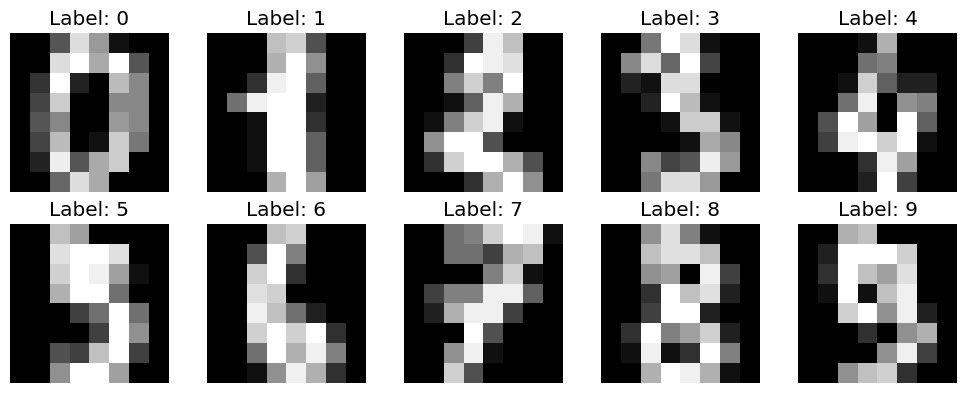

In [2]:
# ============================================================
# SECTION 5.2 — LOAD DATASET
# ============================================================

# Load the Digits dataset
digits = load_digits()

# Create a DataFrame for easier exploration
df = pd.DataFrame(digits.data, columns=[f'pixel_{i}' for i in range(digits.data.shape[1])])
df['target'] = digits.target

# Display basic information
print(f"Dataset Shape: {df.shape}")
print("-" * 50)
df.info()

print("\n--- Descriptive Statistics (first 5 features) ---")
display(df.describe().iloc[:, :5])

print("\n--- Class Distribution ---")
print(df['target'].value_counts().sort_index())

# Visualize some sample digit images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {digits.target[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()


### 💡 TIP for EDA
KNN is **EXTREMELY** sensitive to feature scale — it is purely distance-based. A feature with range 0-255 (pixel intensities) will dominate over a feature with range 0-1. StandardScaler is mandatory. Also, with 64 features, KNN may suffer from the Curse of Dimensionality — consider PCA dimensionality reduction in larger scale problems.

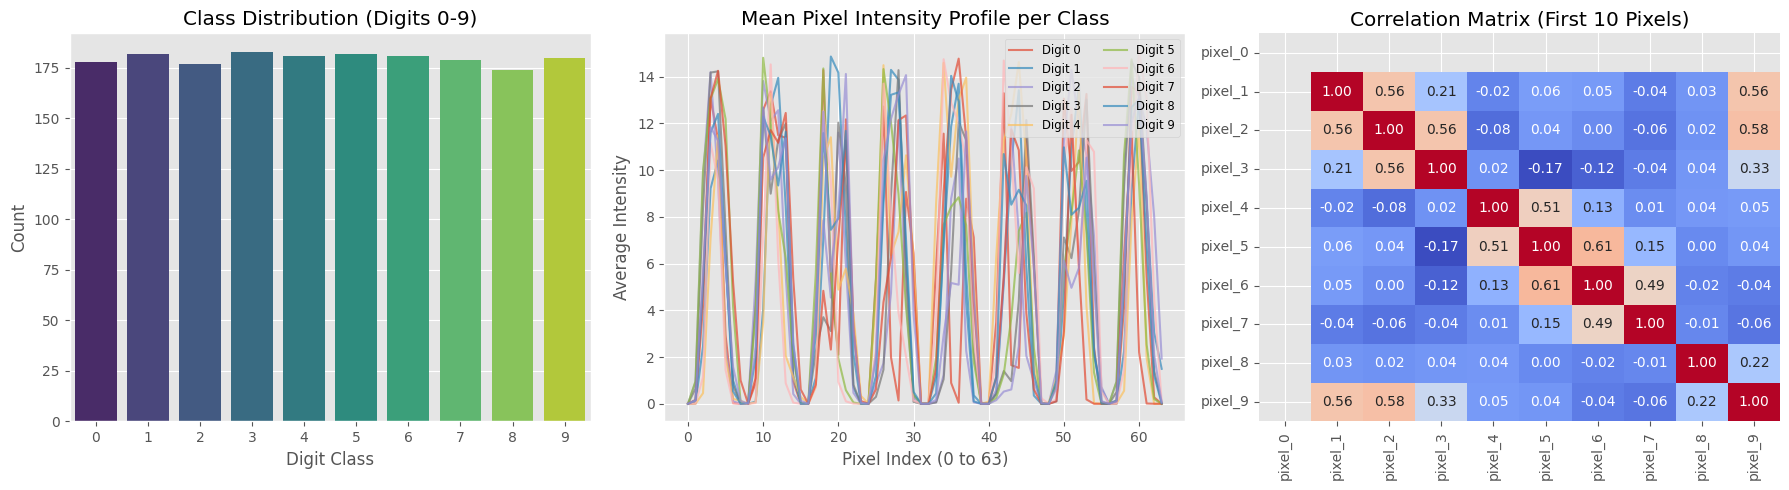

In [3]:
# ============================================================
# SECTION 5.3 — EDA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class Distribution Bar Chart
sns.countplot(x='target', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Class Distribution (Digits 0-9)')
axes[0].set_xlabel('Digit Class')
axes[0].set_ylabel('Count')

# 2. Mean Pixel Intensity per Class
mean_pixels = df.groupby('target').mean()
for i in range(10):
    axes[1].plot(mean_pixels.loc[i].values, label=f'Digit {i}', alpha=0.7)
axes[1].set_title('Mean Pixel Intensity Profile per Class')
axes[1].set_xlabel('Pixel Index (0 to 63)')
axes[1].set_ylabel('Average Intensity')
axes[1].legend(loc='upper right', fontsize='small', ncol=2)

# 3. Correlation Heatmap (First 10 features for readability)
corr = df.iloc[:, :10].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2], cbar=False)
axes[2].set_title('Correlation Matrix (First 10 Pixels)')

plt.tight_layout()
plt.show()


### 💡 SECTION 5.4 TIPS: Preprocessing & Scaling
**CRITICAL:** Explain that for KNN, scaling is not optional — it is mandatory. Unscaled features will cause the distance metric to be dominated by high-magnitude features. `StandardScaler` centers (mean=0) and scales (std=1) each feature independently. Also mention: for image data, pixel values [0,255] can be simply divided by 255.0 as an alternative.

In [4]:
# ============================================================
# SECTION 5.4 — PREPROCESSING
# ============================================================

X = digits.data.copy()
y = digits.target.copy()

# NOTE: We will fit our StandardScaler ONLY on the training set 
# in Section 6 to prevent data leakage.


## 6. Training the Model

In [5]:
# ============================================================
# SECTION 6.1 — TRAIN / VAL / TEST SPLIT
# ============================================================

# First split: 60% Train, 40% Temp (Val/Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)

# Second split: 20% Val, 20% Test (from the 40% Temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train set size:      {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size:       {X_test.shape[0]} samples")

# Scale the features
scaler = StandardScaler()
# Fit only on X_train
X_train_scaled = scaler.fit_transform(X_train)
# Transform val and test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
# Scale temp for cross validation later
X_temp_scaled = scaler.transform(X_temp)


Train set size:      1078 samples
Validation set size: 359 samples
Test set size:       360 samples


### 💡 TIP: Choosing K and Algorithm Backend
- **Rule of thumb:** Start with $K = \sqrt{N_{train}}$. For N=1000, try K≈31.
- **Odd K** for binary classification avoids ties.
- **algorithm:** `'ball_tree'` and `'kd_tree'` are fast for low/medium dimensions. `'brute'` is $O(N \cdot p)$ — use for high-dim or small datasets. `'auto'` lets sklearn decide.
- **leaf_size:** affects BallTree/KDTree build time and query speed.
- **weights='distance':** gives more influence to closer neighbors; often better than uniform.

In [6]:
# ============================================================
# SECTION 6.2 — FIT THE MODEL
# ============================================================

knn = KNeighborsClassifier(
    n_neighbors=5, 
    weights='uniform', 
    metric='euclidean'
)

# Fit the model on training data
knn.fit(X_train_scaled, y_train)

# Evaluate on Train and Val
train_preds = knn.predict(X_train_scaled)
val_preds = knn.predict(X_val_scaled)

print(f"Train accuracy:      {accuracy_score(y_train, train_preds):.4f}")
print(f"Validation accuracy: {accuracy_score(y_val, val_preds):.4f}")


Train accuracy:      0.9861
Validation accuracy: 0.9610


## 7. Validation

In [7]:
# ============================================================
# SECTION 7.1 — CROSS-VALIDATION
# ============================================================

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=cv_strategy, scoring='accuracy')

print(f"Cross-Validation Accuracies: {np.round(cv_scores, 4)}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Cross-Validation Accuracies: [0.9722 0.963  0.9722 0.9721 0.9581]
Mean CV Accuracy: 0.9675 ± 0.0059


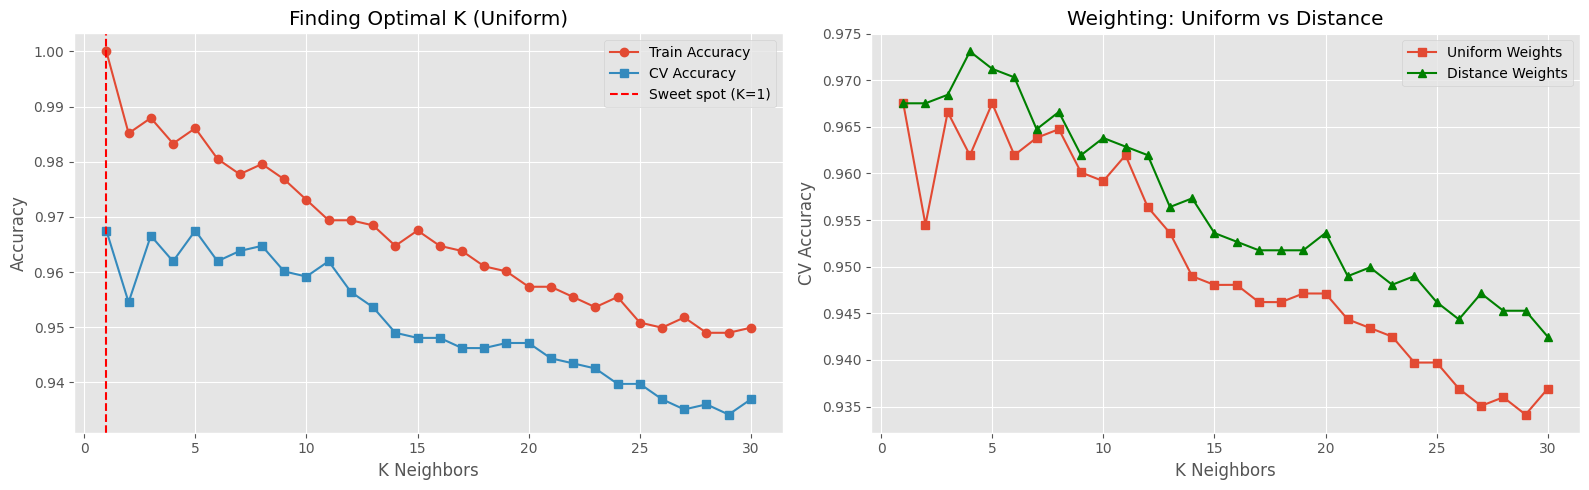

In [8]:
# ============================================================
# SECTION 7.2 — FINDING OPTIMAL K
# ============================================================

k_range = range(1, 31)
train_scores = []
cv_mean_scores = []
cv_distance_scores = []

for k in k_range:
    # Uniform weighting
    knn_u = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn_u.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, knn_u.predict(X_train_scaled)))
    cv_acc_u = cross_val_score(knn_u, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_mean_scores.append(cv_acc_u.mean())
    
    # Distance weighting
    knn_d = KNeighborsClassifier(n_neighbors=k, weights='distance')
    cv_acc_d = cross_val_score(knn_d, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_distance_scores.append(cv_acc_d.mean())

best_k = k_range[np.argmax(cv_mean_scores)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Train vs CV
axes[0].plot(k_range, train_scores, label='Train Accuracy', marker='o')
axes[0].plot(k_range, cv_mean_scores, label='CV Accuracy', marker='s')
axes[0].axvline(x=best_k, color='red', linestyle='--', label=f'Sweet spot (K={best_k})')
axes[0].set_title('Finding Optimal K (Uniform)')
axes[0].set_xlabel('K Neighbors')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Subplot 2: Uniform vs Distance
axes[1].plot(k_range, cv_mean_scores, label='Uniform Weights', marker='s')
axes[1].plot(k_range, cv_distance_scores, label='Distance Weights', marker='^', color='green')
axes[1].set_title('Weighting: Uniform vs Distance')
axes[1].set_xlabel('K Neighbors')
axes[1].set_ylabel('CV Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


### 🩺 Explaining Metrics for Handwritten Digits
Explain: With 10 classes, accuracy is meaningful (balanced dataset). Macro avg gives equal weight to each digit class. Look at per-class precision/recall in the classification report to identify which digits are hardest to classify (e.g., 3 vs 8, 4 vs 9).

## 8. Testing

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.92      0.97      0.95        37
           2       0.97      0.94      0.96        35
           3       0.95      1.00      0.97        37
           4       1.00      0.94      0.97        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       0.95      1.00      0.97        36
           8       0.97      0.89      0.93        35
           9       1.00      1.00      1.00        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360



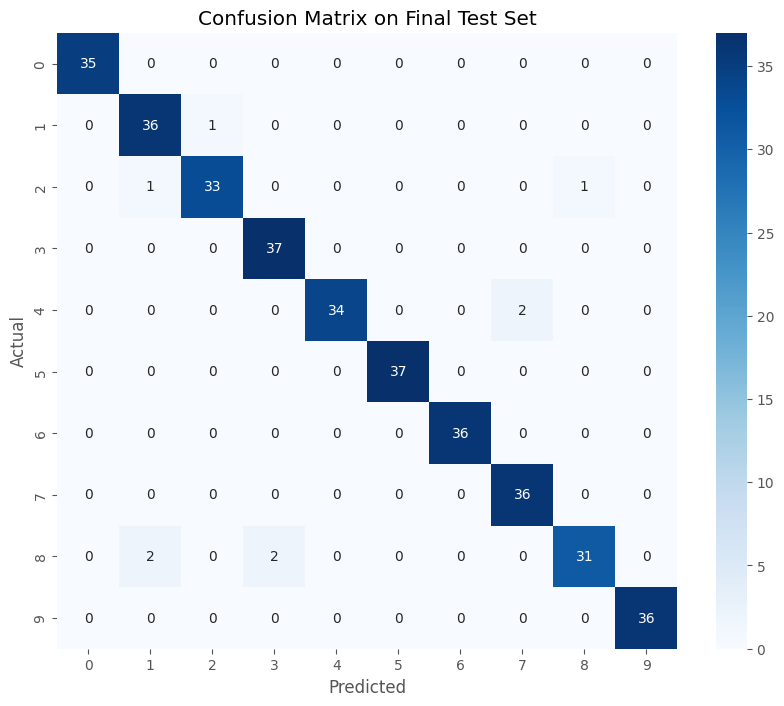

In [9]:
# ============================================================
# SECTION 8.1 & 8.2 — FINAL TEST EVAL & CONFUSION MATRIX
# ============================================================

final_knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance', metric='euclidean')
final_knn.fit(X_train_scaled, y_train)

y_test_pred = final_knn.predict(X_test_scaled)

print("CLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix on Final Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


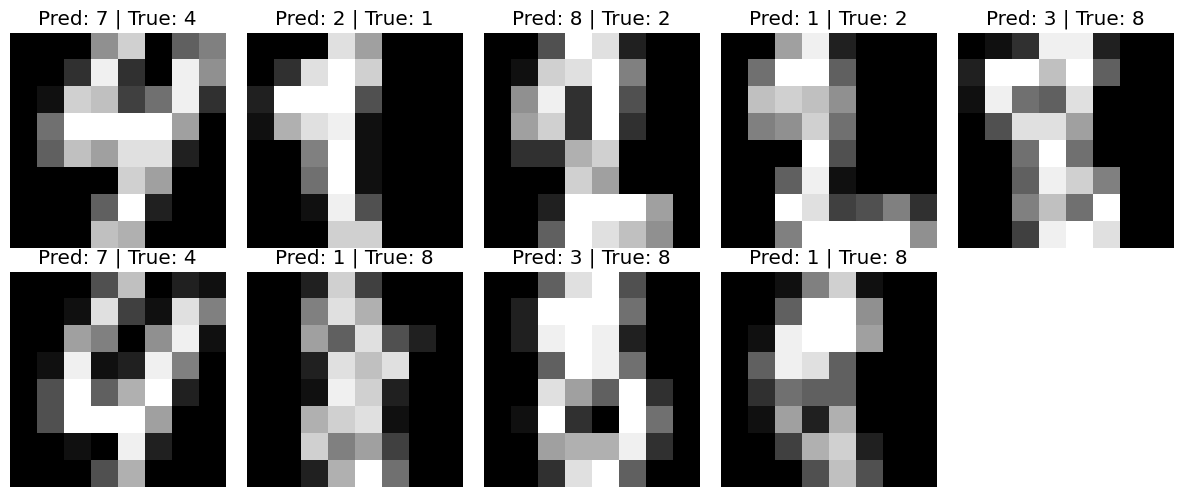

In [10]:
# ============================================================
# SECTION 8.3 — MISCLASSIFIED EXAMPLES
# ============================================================

misclassified_idx = np.where(y_test_pred != y_test)[0]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(min(10, len(misclassified_idx))):
    idx = misclassified_idx[i]
    # Fetch original unscaled data to display image properly
    img = X_test[idx].reshape(8, 8)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Pred: {y_test_pred[idx]} | True: {y_test[idx]}")
    axes[i].axis('off')

for j in range(len(misclassified_idx), 10):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## 9. Optimization & Hyperparameter Tuning

### 💡 TIP: GridSearchCV for KNN
KNN's GridSearch is fast (no expensive training step). The main params to tune: `n_neighbors`, `weights`, `metric` (and `p` for Minkowski). Try a broad range of K first, then refine.

In [11]:
# ============================================================
# SECTION 9.1 — GRIDSEARCHCV
# ============================================================

param_grid = {
    'n_neighbors': list(range(1, 21, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit on validation-temp subset for broader search
grid_search.fit(X_temp_scaled, y_temp)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV Score: 0.9680


In [12]:
# ============================================================
# SECTION 9.2 — BEST PARAMETERS & RETRAIN
# ============================================================

best_model = grid_search.best_estimator_
opt_preds = best_model.predict(X_test_scaled)

print(f"Optimized Test Accuracy: {accuracy_score(y_test, opt_preds):.4f}\n")
print(classification_report(y_test, opt_preds))


Optimized Test Accuracy: 1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       1.00      1.00      1.00        35
           9       1.00      1.00      1.00        36

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



## 10. Decision Boundary Visualization
Explain: To see how K affects the decision boundary, we use a 2D synthetic dataset (2 features, 3 classes). We compare K=1, 5, 15, 50.

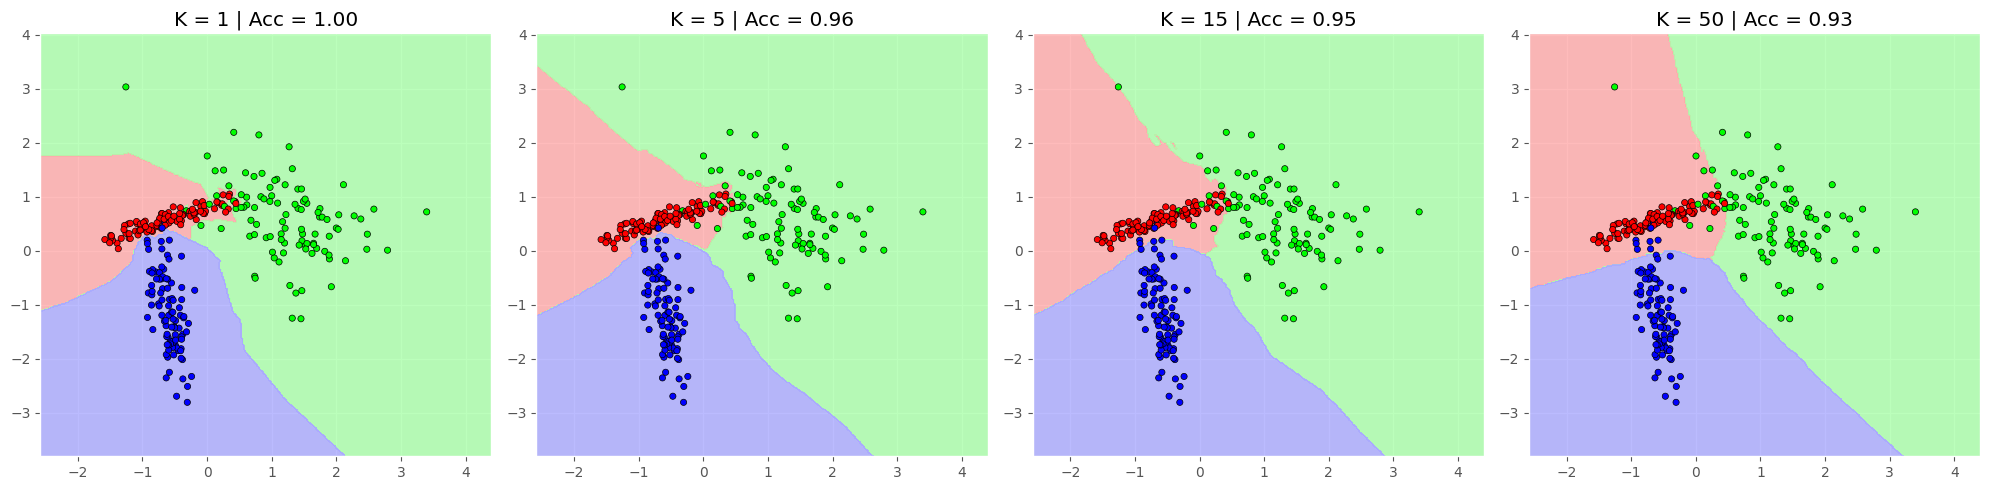

In [13]:
# ============================================================
# SECTION 10 — DECISION BOUNDARY
# ============================================================

from matplotlib.colors import ListedColormap

X_2d, y_2d = make_classification(
    n_samples=300, n_features=2, n_informative=2, n_redundant=0, 
    n_classes=3, n_clusters_per_class=1, random_state=42
)

scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, k in enumerate([1, 5, 15, 50]):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_2d_scaled, y_2d)
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    acc = accuracy_score(y_2d, clf.predict(X_2d_scaled))
    
    axes[idx].contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    axes[idx].scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y_2d, cmap=cmap_bold, edgecolor='k', s=20)
    axes[idx].set_title(f"K = {k} | Acc = {acc:.2f}")
    axes[idx].set_xlim(xx.min(), xx.max())
    axes[idx].set_ylim(yy.min(), yy.max())

plt.tight_layout()
plt.show()


## 11. Tips & Tricks Summary
1. **Always Scale Features**: Distance metrics require scaled data.
2. **Optimal K**: Start with $\sqrt{N_{train}}$.
3. **Odd K**: Use odd values to avoid classification ties.
4. **Distance Weighting**: Usually performs better when data is noisy or imbalanced.
5. **Algorithm Choice**: KD_Tree/Ball_Tree for low dim, Brute force for high dim.
6. **Curse of Dimensionality**: High dimensions ruin distance metrics. Consider PCA.
7. **Memory Issues**: KNN memorizes training data. Use approximate nearest neighbors for massive datasets.
8. **GridSearchCV**: It's fast on KNN because there's no real training phase.
9. **Metric Tuning**: Try Manhattan for high dimensions, Euclidean otherwise.
10. **Avoid with Imbalance**: Predicts majority easily if uniform weighting and K is large.

## 12. Conclusion
K-Nearest Neighbors is a foundational algorithm that beautifully demonstrates the power of instance-based learning. By discarding a complex parametric training phase in favor of simple spatial geometry, KNN achieves remarkable flexibility. It adapts naturally to multi-class problems, makes zero assumptions about underlying data distributions, and provides highly interpretable predictions.

However, its simplicity comes with distinct tradeoffs. The heavy computational burden at prediction time and extreme sensitivity to feature scaling and dimensionality make it ill-suited for large-scale, high-dimensional, or latency-sensitive applications. Despite these limitations, when appropriately tuned and applied to suitable datasets, KNN remains a formidable and deeply educational classification tool in the machine learning arsenal.